# Importing all the Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Loading the dataset

In [3]:
df = pd.read_csv(r"C:\Users\mudda\Downloads\archive (26)\WA_Fn-UseC_-HR-Employee-Attrition.csv")

# Understanding the Dataset

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

# Drop useless columns 

In [5]:
df.drop(columns = ['EmployeeCount','Over18','StandardHours','EmployeeNumber'], axis = 1, inplace=True)

# Clening the dataset

In [6]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

###### No null values

In [7]:
df.duplicated().sum()

np.int64(0)

##### No duplicate values

In [8]:
# Fixing datatypes
cols = [
    "Education","EnvironmentSatisfaction","JobInvolvement",
    "JobLevel","JobSatisfaction","PerformanceRating",
    "RelationshipSatisfaction","StockOptionLevel","WorkLifeBalance"
]

for col in cols:
    df[col] = df[col].astype("category")

In [9]:
# make target category
df["Attrition"] = df["Attrition"].astype("category")

##### Makes the correlation matrix better

# EDA

# Categorical Columns

In [10]:
cat_cols = df.select_dtypes(include=['object','category']).columns

In [11]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:
    print("\n------------------------------")
    print(f"Column: {col}")
    print("------------------------------")
    print(df[col].value_counts())
    print("Total:", df[col].count())


------------------------------
Column: Attrition
------------------------------
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Total: 1470

------------------------------
Column: BusinessTravel
------------------------------
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64
Total: 1470

------------------------------
Column: Department
------------------------------
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64
Total: 1470

------------------------------
Column: Education
------------------------------
Education
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64
Total: 1470

------------------------------
Column: EducationField
------------------------------
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resource

📊 Exploratory Data Analysis – Key Insights

🔹 Attrition

The overall employee attrition rate is approximately 16%, indicating moderate turnover within the organization.

🔹 Workforce Composition

The company workforce is male-dominated (60%).

A significant majority of employees (65%) belong to the Research & Development department.

🔹 Experience Level

The organizational structure is junior-heavy.

Approximately 73% of employees are at Job Level 1 or 2, suggesting a pyramid-shaped hierarchy.

🔹 Satisfaction Levels

Overall employee sentiment appears positive.

Most employees report Job, Environment, and Relationship Satisfaction levels of 3 or 4, indicating moderate to high satisfaction.

🔹 Work-Life Balance

Around 60% of employees report a Work-Life Balance level of 3.

However, 28% of employees work overtime, which may influence future attrition.

🔹 Stock Options

A large proportion (43%) of employees have no stock options, which could potentially impact long-term retention.

🔹 Performance Ratings

The majority (85%) of employees are rated at Performance Level 3 ("Excellent").

Only 15% achieve Level 4 ("Outstanding"), showing limited variation in performance ratings.

# Numerical Columns

In [12]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    print("\n------------------------------")
    print(f"Column: {col}")
    print("------------------------------")
    print(df[col].describe())
    print("Skewness:", df[col].skew().round(2))


------------------------------
Column: Age
------------------------------
count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64
Skewness: 0.41

------------------------------
Column: DailyRate
------------------------------
count    1470.000000
mean      802.485714
std       403.509100
min       102.000000
25%       465.000000
50%       802.000000
75%      1157.000000
max      1499.000000
Name: DailyRate, dtype: float64
Skewness: -0.0

------------------------------
Column: DistanceFromHome
------------------------------
count    1470.000000
mean        9.192517
std         8.106864
min         1.000000
25%         2.000000
50%         7.000000
75%        14.000000
max        29.000000
Name: DistanceFromHome, dtype: float64
Skewness: 0.96

------------------------------
Column: HourlyRate
------------------------------
count    1470.000000
mean   

📊 Numerical Analysis – Key Insights

🔹 Age

The average employee age is 37 years, with the workforce ranging from 18 to 60 years old.

🔹 Monthly Income

Compensation is right-skewed, with a median income of $4,919 compared to a higher mean of $6,503, indicating a smaller group of high earners.

🔹 Distance from Home

Approximately 75% of employees live within 14 miles of the workplace.

The maximum commute distance reaches 29 miles, suggesting a few long-distance commuters.

🔹 Tenure

The median tenure at the company is 5 years.

Employees typically remain in their current role for 3 years.

🔹 Promotions

Around 50% of employees have experienced a promotion or role change within the past year, indicating internal mobility.

🔹 Total Experience

Employees average 11 total working years.

On average, employees have worked at nearly 3 companies, reflecting moderate career mobility.

🔹 Salary Hike

The median annual salary increase is 14%, with a maximum of 25%, suggesting competitive raise policies.

🔹 Training

Professional development appears consistent, with employees attending approximately 3 training sessions per year on average.

# Visualization

### categorical v attrition

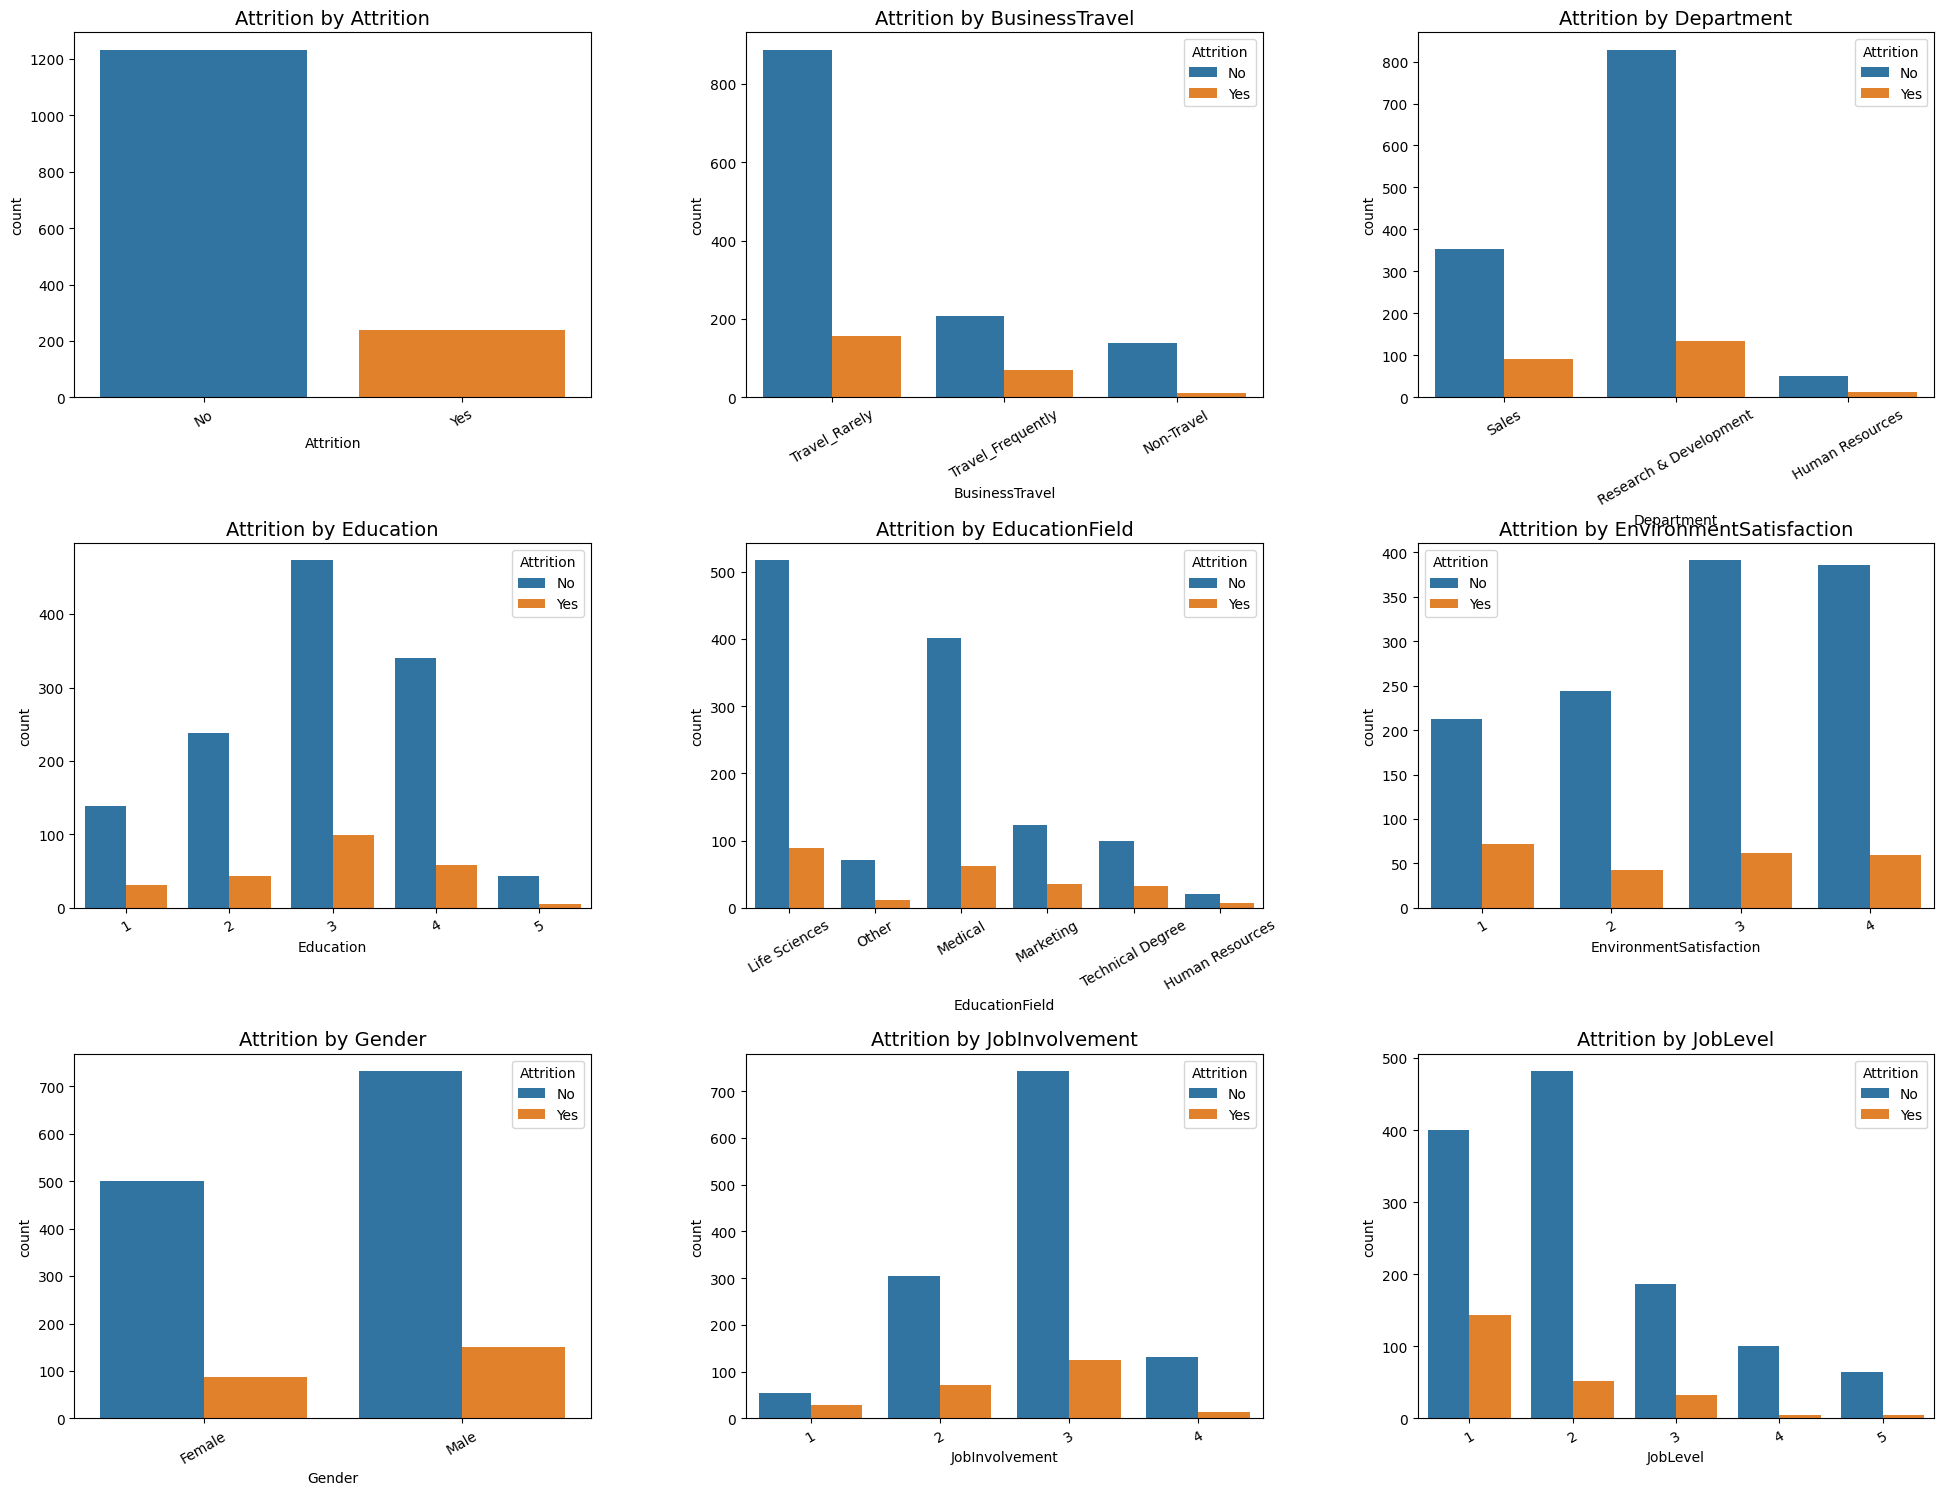

In [13]:
cat_cols = df.select_dtypes(include=['object','category']).columns

fig, axes = plt.subplots(3, 3, figsize=(24, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols[:9]):
    sns.countplot(data=df, x=col, hue="Attrition", ax=axes[i])
    axes[i].set_title(f"Attrition by {col}", fontsize=14)
    axes[i].tick_params(axis='x', rotation=30)

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

📊 Categorical Variables vs Attrition – Key Insights
🔹 Job Level (Strongest Impact)

Attrition is significantly higher among Job Level 1 employees and steadily decreases as job level increases. Senior employees (Levels 4–5) show very low attrition.
This suggests early-career employees are most vulnerable to leaving.

🔹 Business Travel

Employees who travel frequently show noticeably higher attrition compared to those who travel rarely or not at all.
Frequent travel may contribute to burnout or work-life imbalance.

🔹 Job Involvement

Lower job involvement levels correspond with higher attrition.
Employees with high involvement (Level 3–4) appear more stable.

🔹 Environment Satisfaction

Employees with lower environment satisfaction (Levels 1–2) exhibit higher attrition rates.
Workplace environment plays a meaningful role in retention.

🔹 Department

Although Research & Development has the highest number of exits, this is largely due to its large workforce size.
Attrition rate percentages are needed for a fair comparison across departments.

🔹 Gender & Education

Gender and education levels do not show a strong visible impact on attrition based on raw distribution.
Their influence appears weaker compared to job structure and engagement-related factors.

### Numerical v attrition

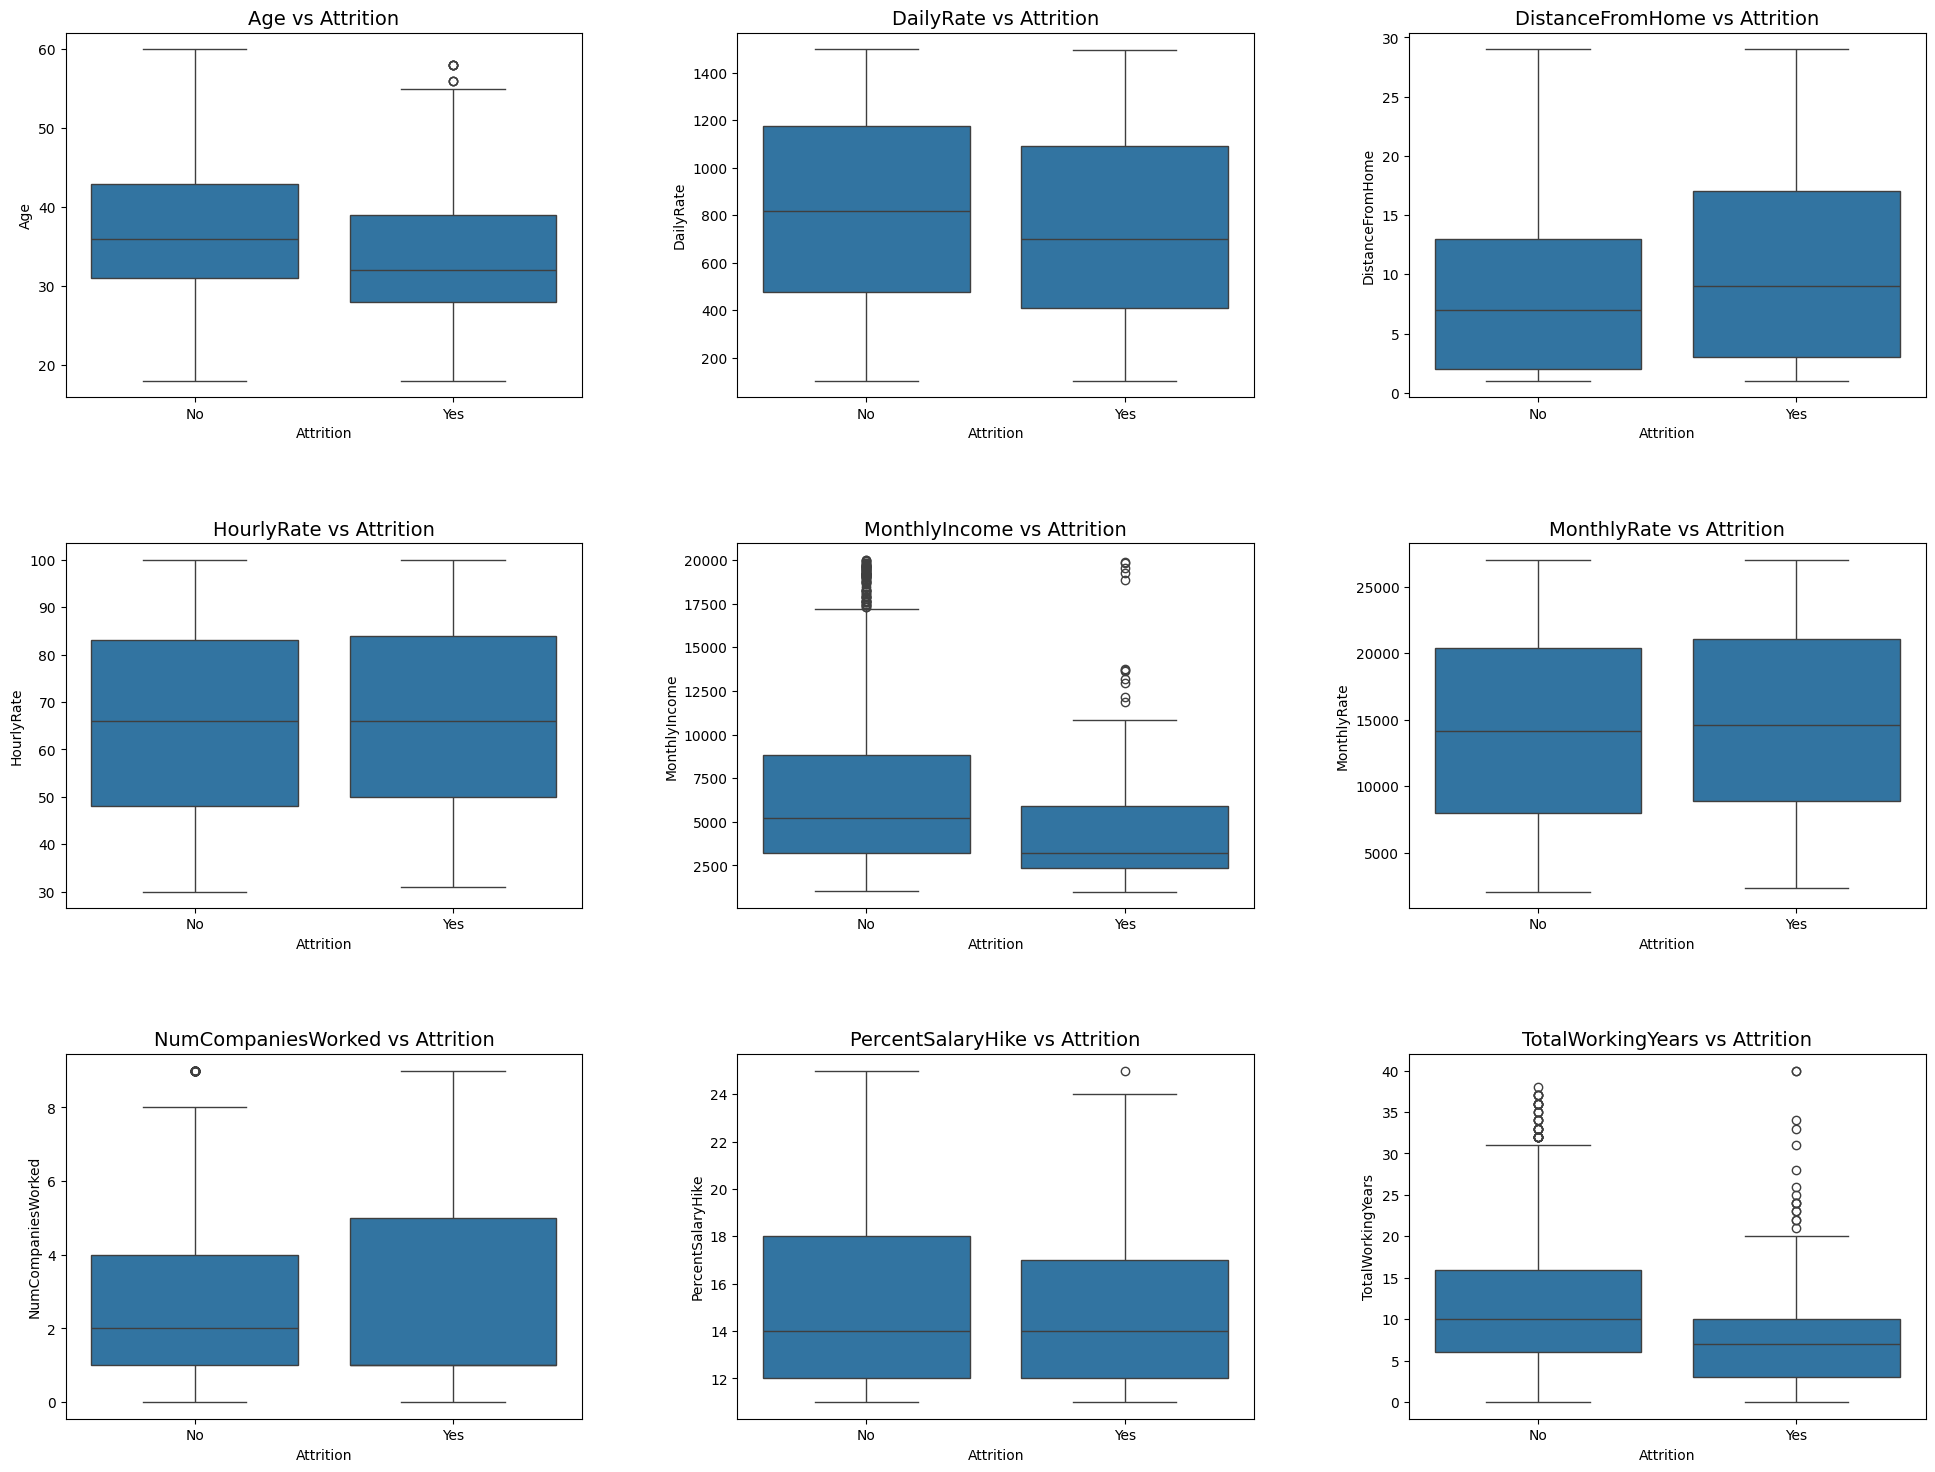

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(24, 18))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if i < len(axes):
        sns.boxplot(data=df, x="Attrition", y=col, ax=axes[i])
        axes[i].set_title(f"{col} vs Attrition", fontsize=14)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

Add this as a Markdown cell under your numerical boxplots:

📊 Numerical Variables vs Attrition – Key Insights
🔹 Age

Employees who left the company tend to be slightly younger than those who stayed.
This suggests higher turnover among early-career employees.

🔹 Monthly Income

Employees who left generally have a lower median monthly income compared to those who stayed.
Compensation appears to be a significant retention factor.

🔹 Distance From Home

Employees who left show a slightly higher commute distance on average.
Longer commute may contribute moderately to attrition.

🔹 Years at Company

Employees who left typically have fewer years at the company.
Attrition is notably higher among employees in their early tenure stage.

🔹 Total Working Years

Employees who left tend to have less overall career experience, reinforcing the trend of early-career turnover.

🔹 Percent Salary Hike

There is no strong visible difference in salary hike percentages between employees who stayed and those who left.
This suggests annual raises may not significantly influence attrition.

🔹 Training Times Last Year

Training frequency appears similar across both groups, indicating limited impact on attrition.

### Atrrition rate by Department

In [16]:
attrition_rate = (
    df.groupby('Department')['Attrition'].value_counts(normalize=True).mul(100).rename('Rate').reset_index()
)

attrition_yes = attrition_rate[attrition_rate['Attrition'] == 'Yes']

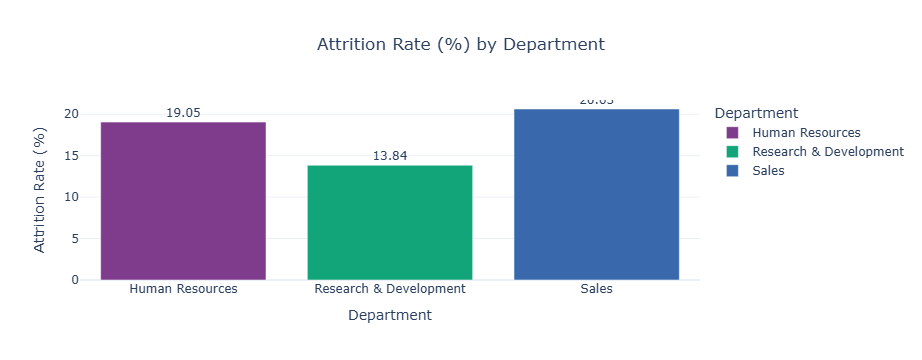

In [17]:
fig = px.bar(
    attrition_yes,
    x="Department",
    y="Rate",
    title="Attrition Rate (%) by Department",
    text=attrition_yes["Rate"].round(2),
    color="Department",
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_traces(textposition="outside")

fig.update_layout(
    yaxis_title="Attrition Rate (%)",
    xaxis_title="Department",
    title_x=0.5,
    template="plotly_white"
)

fig.show()

🔹 Sales (Highest Attrition – ~20%)

The Sales department shows the highest attrition rate (~20%).
This suggests sales roles may involve higher pressure, performance targets, or burnout risk.

🔹 Human Resources (~19%)

HR also shows a relatively high attrition rate (~19%), despite having a smaller workforce.
This may indicate structural or workload-related challenges within HR.

🔹 Research & Development (Lowest – ~14%)

R&D has the lowest attrition rate (~14%).
This suggests stronger stability, potentially due to role specialization, project continuity, or job engagement.

### Attrition rate by Jobrole

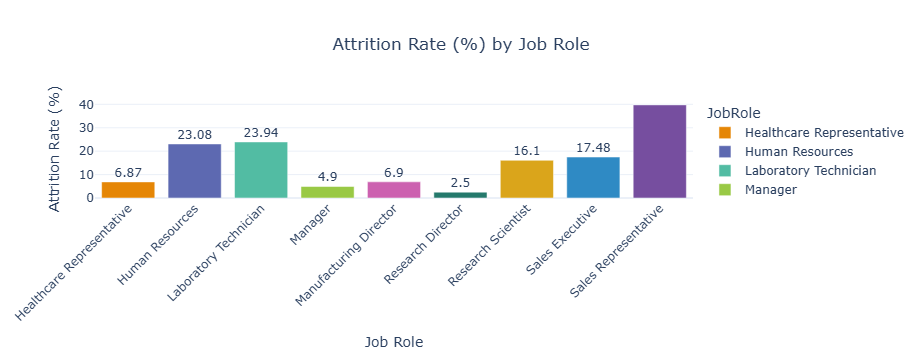

In [ ]:
attrition_role = (
    df.groupby("JobRole")["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Rate")
    .reset_index()
)

attrition_role_yes = attrition_role[attrition_role["Attrition"] == "Yes"]

fig = px.bar(
    attrition_role_yes,
    x="JobRole",
    y="Rate",
    color="JobRole",
    text=attrition_role_yes["Rate"].round(2),
    title="Attrition Rate (%) by Job Role",
    color_discrete_sequence=px.colors.qualitative.Vivid
)

fig.update_traces(textposition="outside")
fig.update_layout(
    xaxis_title="Job Role",
    yaxis_title="Attrition Rate (%)",
    xaxis_tickangle=-45,
    title_x=0.5,
    template="plotly_white"
)

fig.show()

Sales Representative shows the highest attrition (~40%), indicating severe instability.

Laboratory Technicians and HR roles also demonstrate elevated turnover (~23–24%).

Senior roles such as Research Director and Manager show very low attrition (<5%).

Attrition is structurally concentrated in junior and performance-driven roles.

### Income v Years at the company

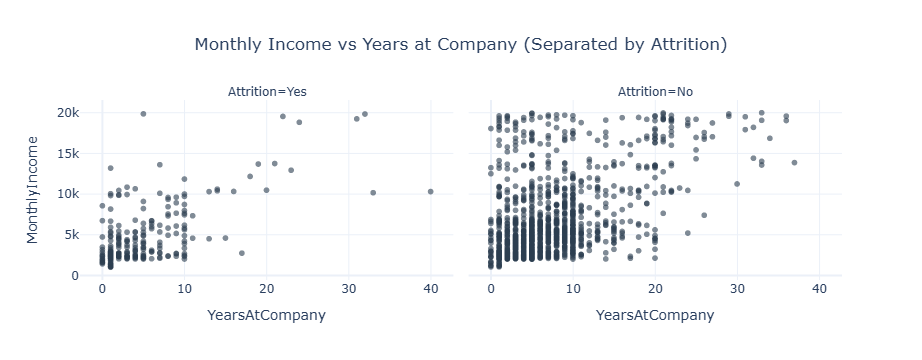

In [19]:
fig = px.scatter(
    df,
    x="YearsAtCompany",
    y="MonthlyIncome",
    facet_col="Attrition",
    color_discrete_sequence=["#2c3e50"],
    opacity=0.6,
    template="plotly_white",
    title="Monthly Income vs Years at Company (Separated by Attrition)"
)

fig.update_traces(marker=dict(size=6))
fig.update_layout(title_x=0.5)

fig.show()

Attrition is concentrated among employees with lower tenure (0–10 years) and lower income levels.
Employees with longer tenure and higher salaries show significantly greater stability.

This suggests that early-career and lower-compensated employees are at the highest risk of leaving.

### Attrition by Work Life Balance

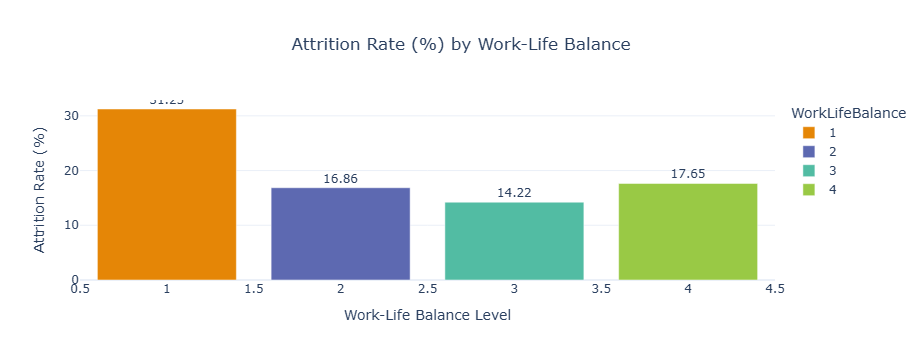

In [20]:
wlb_rate = (
    df.groupby("WorkLifeBalance", observed=False)["Attrition"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Rate")
      .reset_index()
)

wlb_yes = wlb_rate[wlb_rate["Attrition"] == "Yes"]

fig = px.bar(
    wlb_yes,
    x="WorkLifeBalance",
    y="Rate",
    color="WorkLifeBalance",
    text=wlb_yes["Rate"].round(2),
    title="Attrition Rate (%) by Work-Life Balance",
    color_discrete_sequence=px.colors.qualitative.Vivid
)

fig.update_traces(textposition="outside")
fig.update_layout(
    yaxis_title="Attrition Rate (%)",
    xaxis_title="Work-Life Balance Level",
    title_x=0.5,
    template="plotly_white"
)

fig.show()

Employees reporting the lowest work-life balance (Level 1) exhibit the highest attrition rate (~31%). Attrition significantly decreases among employees with moderate to high work-life balance, indicating that poor balance is a major turnover driver.

### Attrition by Job satisfaction

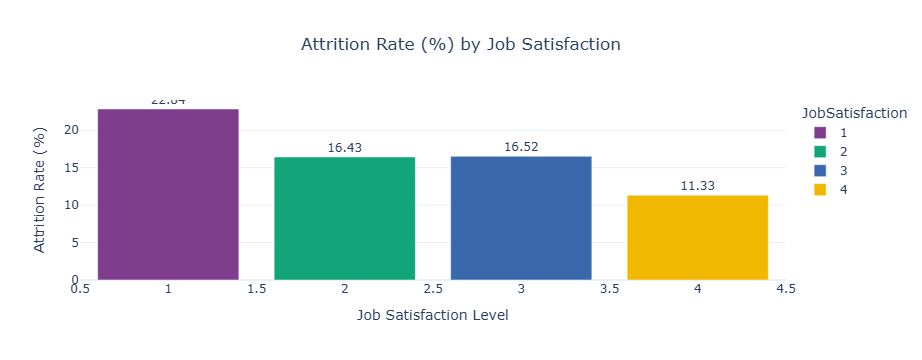

In [ ]:
js_rate = (
    df.groupby("JobSatisfaction", observed=False)["Attrition"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Rate")
    .reset_index()
)

js_yes = js_rate[js_rate["Attrition"] == "Yes"]

fig = px.bar(
    js_yes,
    x="JobSatisfaction",
    y="Rate",
    color="JobSatisfaction",
    text=js_yes["Rate"].round(2),
    title="Attrition Rate (%) by Job Satisfaction",
    color_discrete_sequence=px.colors.qualitative.Bold
)

fig.update_traces(textposition="outside")
fig.update_layout(
    yaxis_title="Attrition Rate (%)",
    xaxis_title="Job Satisfaction Level",
    title_x=0.5,
    template="plotly_white"
)

fig.show()

Employees with low job satisfaction (Level 1) show significantly higher attrition, While those better satisfaction show less attrition

## Correlation Heatmap

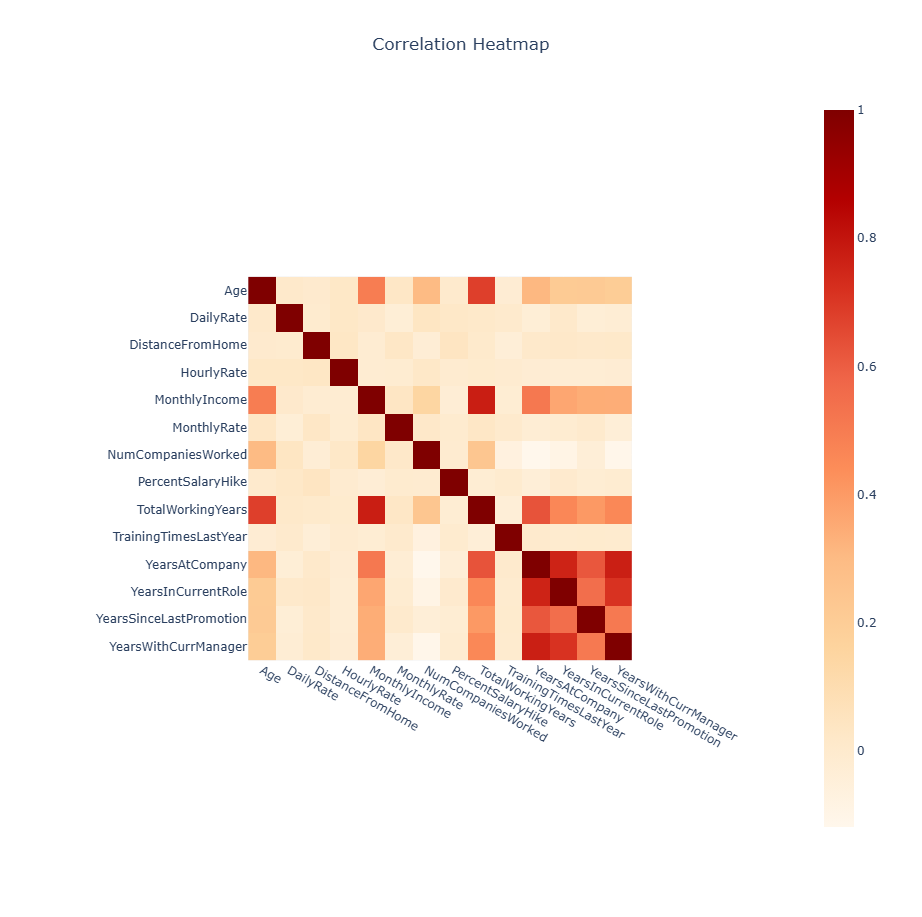

In [27]:
corr = df.corr(numeric_only=True)

fig = px.imshow(
    corr,
    color_continuous_scale="OrRd",
    title="Correlation Heatmap"
)

fig.update_layout(
    height=900,
    width=1500,
    title_x=0.5
)

fig.show()

Strong positive correlations exist among tenure-related variables (YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager, YearsSinceLastPromotion), indicating structural overlap. Monthly income is strongly associated with total working years and tenure, reflecting expected compensation growth with experience. Several rate-based variables (DailyRate, HourlyRate, MonthlyRate) show weak correlations and appear structurally independent.

### Monthly income v Attrition

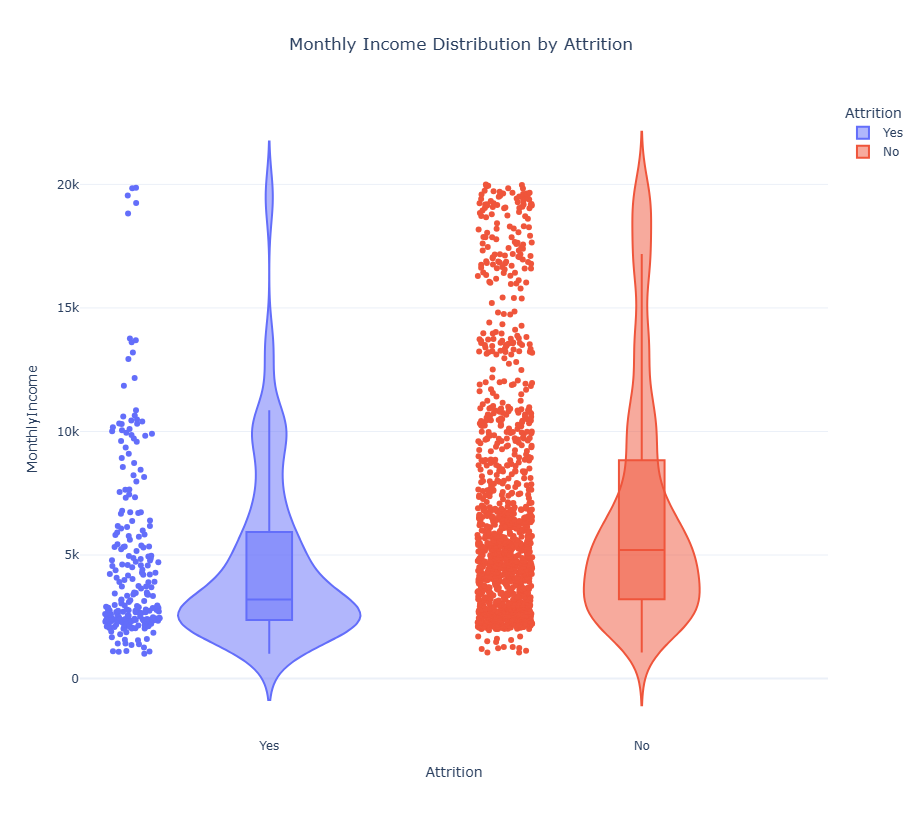

In [30]:
fig = px.violin(
    df,
    x="Attrition",
    y="MonthlyIncome",
    color="Attrition",
    box=True,              # show box inside
    points="all",          # show data points
    template="plotly_white",
    title="Monthly Income Distribution by Attrition"
)

fig.update_layout(
    height=800,
    width=1200,
    title_x=0.5
)

fig.show()

Employees who left are more concentrated in lower income ranges, while higher-income employees demonstrate greater stability. Income distribution is right-skewed, and compensation appears to be a strong retention factor.

# Model Building

In [32]:
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})

### Getting dependent and independent variables

In [33]:
x = df.drop('Attrition', axis=1)
y = df['Attrition']

### Encoding categorical variables

In [34]:
x = pd.get_dummies(x,drop_first=True)

In [37]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [44]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define models
rfc = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

gbdt = GradientBoostingClassifier(n_estimators=200, random_state=42)

xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42,
    eval_metric='logloss'
)

clfs = {
    "Random Forest": rfc,
    "Gradient Boosting": gbdt,
    "XGBoost": xgb
}

# Training function
def train_classifier(clf, x_train, y_train, x_test, y_test):
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return accuracy, precision, recall, f1


# Store results
results = []

for name, clf in clfs.items():
    
    acc, prec, rec, f1 = train_classifier(clf, x_train, y_train, x_test, y_test)
    
    print(f"\n{name}")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1 Score:", round(f1, 4))
    
    results.append([name, acc, prec, rec, f1])


Random Forest
Accuracy: 0.881
Precision: 1.0
Recall: 0.1026
F1 Score: 0.186

Gradient Boosting
Accuracy: 0.881
Precision: 0.6111
Recall: 0.2821
F1 Score: 0.386

XGBoost
Accuracy: 0.8537
Precision: 0.4333
Recall: 0.3333
F1 Score: 0.3768


Gradient Boosting achieved the best balance between precision and recall (F1 ≈ 0.39), making it the most suitable model for predicting employee attrition. Although recall remains moderate, it outperforms Random Forest and XGBoost in overall balance.

# Tuning the Gradient Boost Model

In [45]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report

gb = GradientBoostingClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 0.9, 1.0]
}

In [47]:
random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,30
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [48]:
best_gb = random_search.best_estimator_

print("Best Parameters:", random_search.best_params_)

Best Parameters: {'subsample': 1.0, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 2, 'learning_rate': 0.2}


### Threshold tuning

In [51]:
y_prob = best_gb.predict_proba(x_test)[:,1]

y_pred_adjusted = (y_prob > 0.3).astype(int)

print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.91      0.90      0.91       255
           1       0.40      0.44      0.41        39

    accuracy                           0.84       294
   macro avg       0.65      0.67      0.66       294
weighted avg       0.84      0.84      0.84       294



### Using SMOTE to fix imbalanced Classes

In [55]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

x_train_sm, y_train_sm = smote.fit_resample(x_train, y_train)

In [56]:
print(y_train_sm.value_counts())

Attrition
0    978
1    978
Name: count, dtype: int64


In [57]:
best_gb.fit(x_train_sm, y_train_sm)

y_pred = best_gb.predict(x_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.93      0.92       255
           1       0.47      0.41      0.44        39

    accuracy                           0.86       294
   macro avg       0.69      0.67      0.68       294
weighted avg       0.85      0.86      0.86       294



Applying SMOTE improved minority class detection, increasing the F1 score to 0.44 while maintaining strong overall accuracy (86%). Compared to simple threshold adjustment, SMOTE provided a better balance between precision and recall, making it the most effective approach for handling class imbalance in this project.

## ROC Curve

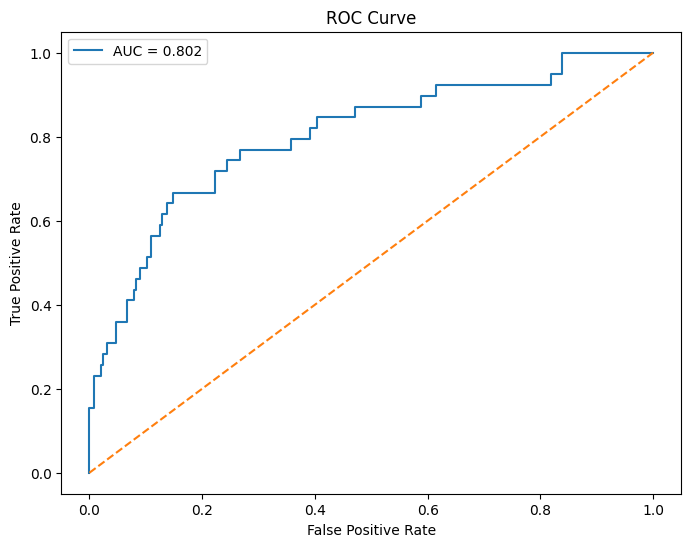

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_prob = best_gb.predict_proba(x_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC curve shows an AUC of 0.802, indicating strong discriminative ability. The model is capable of effectively distinguishing between employees who are likely to leave and those who are not.

## Precision Recall Curve

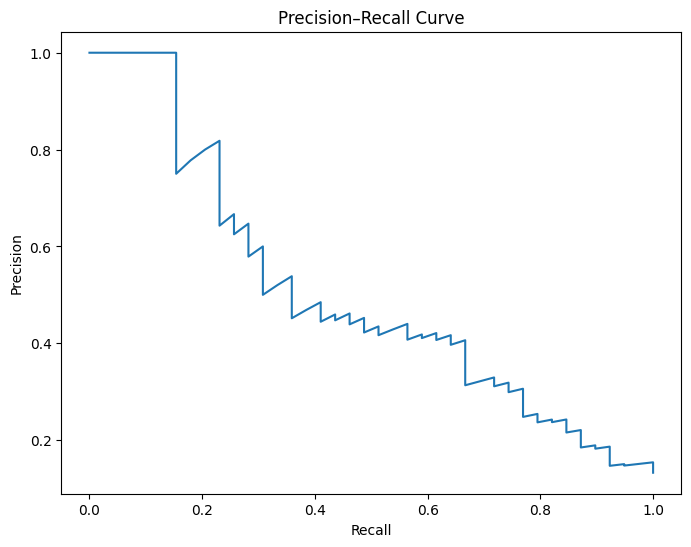

In [60]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.show()

The Precision–Recall curve highlights the trade-off between detecting more attrition cases and maintaining prediction accuracy. In the moderate recall region (~40%), precision remains around 40–50%, representing a balanced operating point suitable for proactive HR intervention.

## Feature Importance

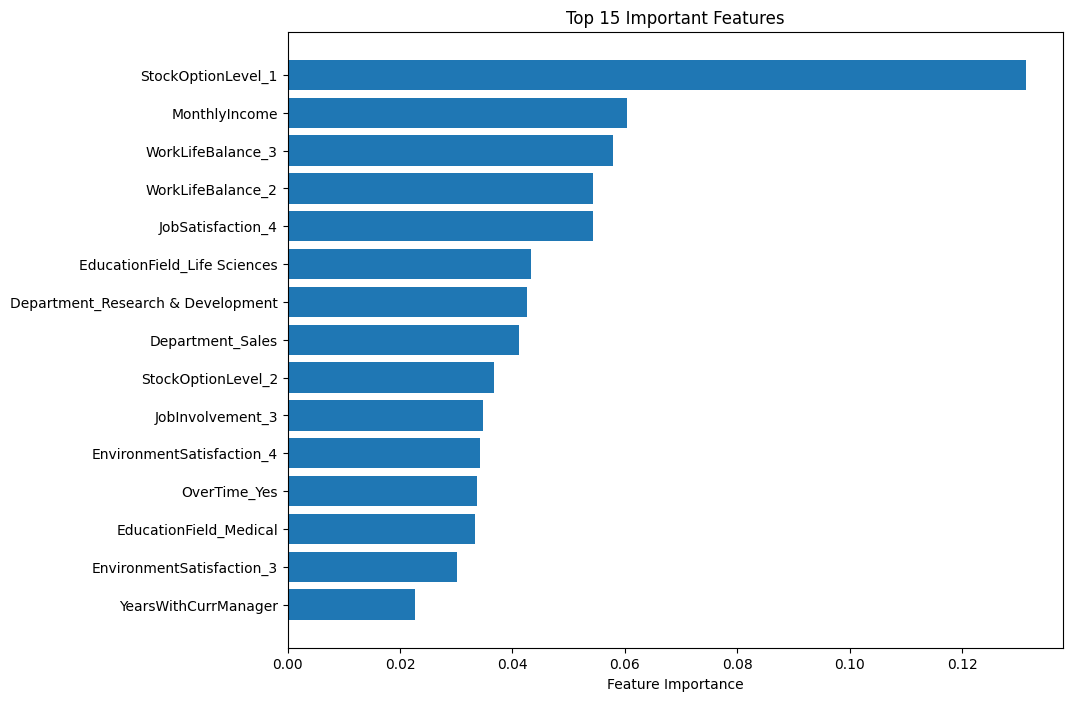

In [64]:
import numpy as np

importance = best_gb.feature_importances_

indices = np.argsort(importance)[-15:] 

plt.figure(figsize=(10,8))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), [x_train.columns[i] for i in indices])
plt.xlabel("Feature Importance")
plt.title("Top 15 Important Features")
plt.show()

Feature importance analysis reveals that compensation-related factors (Stock Option Level and Monthly Income) are the strongest predictors of employee attrition. Work-Life Balance, Job Satisfaction, and Departmental role also play significant roles. These findings suggest that financial incentives and employee well-being are key drivers of retention.

# Saving the Model and the CSV 

In [65]:
import joblib
joblib.dump(best_gb, "model.pkl")

['model.pkl']

In [68]:
# to prevent feature mismatch
joblib.dump(x_train.columns, "columns.pkl")

['columns.pkl']

In [66]:
# analysis data
df.to_csv("data.csv", index=False)

In [67]:
# model data
x.to_csv("model_features.csv", index=False)